<a href="https://colab.research.google.com/github/shuvopodder/Plant-Disease-Prediction/blob/main/Plant_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.tensorflow.org/tutorials/images/cnn

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import RMSprop

In [4]:
dir_path = "./data"
print(dir_path)

./data


In [5]:
train = ImageDataGenerator(rescale=1/255)
validation = ImageDataGenerator(rescale=1/255)

In [6]:
train_dataset = train.flow_from_directory(
    dir_path + "/train/",
    target_size=(200, 200),
    batch_size=32,          # use 32 for faster training
    class_mode='categorical' # since you have 5 classes
)

val_dataset = train.flow_from_directory(
    dir_path + "/val/",
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical'
)


Found 3724 images belonging to 5 classes.
Found 784 images belonging to 5 classes.


In [8]:
# Print all class labels (for reference)
print(train_dataset.class_indices)

# Store label for future use
labels = {v: k for k, v in train_dataset.class_indices.items()}

{'Blight': 0, 'Cob_Root': 1, 'Common_Rust': 2, 'Gray_Leaf_Spot': 3, 'Healthy': 4}


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Flatten + Dense Layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    # Output layer
    Dense(5, activation='softmax')  # 5 classes
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 198, 198, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 97, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 46, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    17,334,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,462,213 (66.61 MB)

 Trainable params: 17,461,765 (66.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset
)

Epoch 1/20


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 505ms/step - accuracy: 0.6998 - loss: 1.2986 - val_accuracy: 0.1913 - val_loss: 4.1102
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 514ms/step - accuracy: 0.7903 - loss: 0.6273 - val_accuracy: 0.4043 - val_loss: 2.7299
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 501ms/step - accuracy: 0.8193 - loss: 0.5503 - val_accuracy: 0.7015 - val_loss: 1.6507
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 58s 499ms/step - accuracy: 0.8378 - loss: 0.4658 - val_accuracy: 0.7666 - val_loss: 0.7673
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 58s 499ms/step - accuracy: 0.8531 - loss: 0.4067 - val_accuracy: 0.8010 - val_loss: 0.5985
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 59s 504ms/step - accuracy: 0.8821 - loss: 0.3327 - val_accuracy: 0.8367 - val_loss: 0.5034
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 60s 511ms/step - accuracy: 0.8988 - loss: 0.2986 - val_accuracy: 0.8533 - val_loss: 0.4155
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 62s 527ms/step - accuracy: 0.9130 - loss: 0.2768 - val

In [12]:
model.save('model-test-lab.h5')

In [13]:
#new updated format
model.save('model-test-lab.keras')

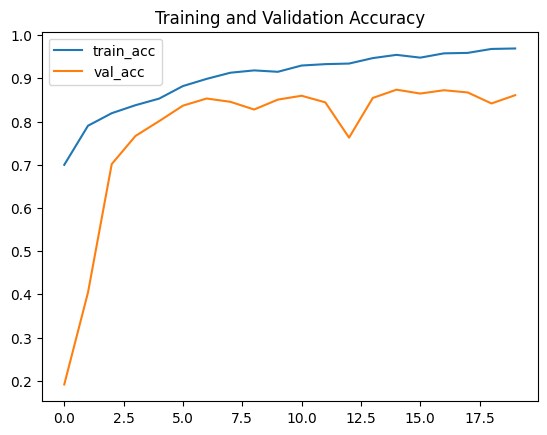

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [9]:
###TEST
import numpy as np
from tensorflow.keras.preprocessing import image
img_path = './data/train/Healthy/Corn_Health (18).jpg'  # your image path

# Load image and resize to the same size used for training
img = image.load_img(img_path, target_size=(200, 200))

# Convert to numpy array
img_array = image.img_to_array(img)

# Scale pixel values (important!)
img_array = img_array / 255.0

# Expand dimensions to match model input shape: (1, 200, 200, 3)
img_array = np.expand_dims(img_array, axis=0)


In [13]:
# Predict
prediction = model.predict(img_array)

# Get class index with highest probability
predicted_class_index = np.argmax(prediction, axis=1)[0]
print("Predicted class index:", predicted_class_index)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted class index: 4


In [1]:
#if failed to get model or name 'model' is not defined error
from tensorflow import keras
# Load model
model = keras.models.load_model("model-test-lab.keras")
# Test it
model.summary()


/opt/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 198, 198, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 97, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 46, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    17,334,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,923,980 (133.22 MB)

 Trainable params: 17,461,765 (66.61 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 17,461,767 (66.61 MB)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Evaluate the model on validation data
val_loss, val_acc = model.evaluate(val_dataset)
print(f"\n Validation Accuracy: {val_acc*100:.2f}%")
print(f" Validation Loss: {val_loss:.4f}")


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.8610 - loss: 0.5945

 Validation Accuracy: 86.10%
 Validation Loss: 0.5945


In [14]:
# Print all class labels (for reference)
print(train_dataset.class_indices)

# Reverse mapping (index → label)
labels = {v: k for k, v in train_dataset.class_indices.items()}

# Get predicted label
predicted_label = labels[predicted_class_index]
print("Predicted label:", predicted_label)


{'Blight': 0, 'Cob_Root': 1, 'Common_Rust': 2, 'Gray_Leaf_Spot': 3, 'Healthy': 4}
Predicted label: Healthy


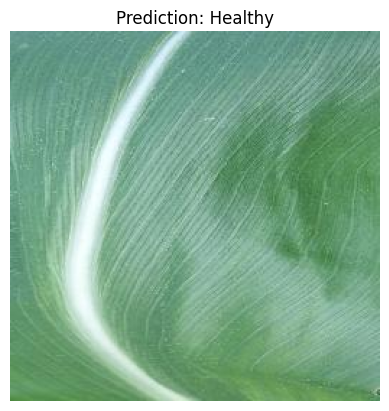

In [15]:
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {predicted_label}")
plt.axis('off')
plt.show()


### Work with label

In [17]:
#appendix to work with label

#option 1
# After training to store the label inside metadata
model.class_names = list(train_dataset.class_indices.keys())
#now can save the model and later can use the label metadata
# Save in .keras format
# model.save("model-test-lab.keras")
#load from file
#model = keras.models.load_model("model-test-lab.keras", safe_mode=False)

# Save in .keras format
print(model.class_names)
#⚠️ Works only for .keras format

['Blight', 'Cob_Root', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [18]:
#option 2
# Save class indices for later
import json
with open("class_indices.json", "w") as f:
    json.dump(train_dataset.class_indices, f)


# Load label mapping
with open("class_indices.json", "r") as f:
    class_indices = json.load(f)

# Reverse mapping (index → label)
labels = {v: k for k, v in class_indices.items()}


In [8]:
# Load label mapping
with open("class_indices.json", "r") as f:
    class_indices = json.load(f)

# Reverse mapping (index → label)
labels = {v: k for k, v in class_indices.items()}


### TFLITE

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


In [25]:
# Load your trained Keras model
model = tf.keras.models.load_model('model-test-lab.h5')
print("✅ Loaded model.h5 successfully!")


✅ Loaded model.h5 successfully!


In [20]:
# Convert the model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model to file
with open('model-test-lab.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Converted to model.tflite and saved successfully!")


INFO:tensorflow:Assets written to: /var/folders/yl/hhw6yxpd0p5886wkxnkl8wd40000gn/T/tmph0dhbrx1/assets


INFO:tensorflow:Assets written to: /var/folders/yl/hhw6yxpd0p5886wkxnkl8wd40000gn/T/tmph0dhbrx1/assets


Saved artifact at '/var/folders/yl/hhw6yxpd0p5886wkxnkl8wd40000gn/T/tmph0dhbrx1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  6386755792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386758288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386759056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386757136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386757328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386756176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386759248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386758864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386761168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386760976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6386761552: TensorSpe

W0000 00:00:1761044224.291972  503123 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1761044224.292181  503123 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-10-21 16:57:04.292722: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/yl/hhw6yxpd0p5886wkxnkl8wd40000gn/T/tmph0dhbrx1
2025-10-21 16:57:04.293231: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-21 16:57:04.293236: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/yl/hhw6yxpd0p5886wkxnkl8wd40000gn/T/tmph0dhbrx1
I0000 00:00:1761044224.297534  503123 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-10-21 16:57:04.298262: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-21 16:57:04.375872: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder

✅ Converted to model.tflite and saved successfully!


In [2]:
# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path='model-test-lab.tflite')
interpreter.allocate_tensors()

# Get input and output tensor info
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

/opt/anaconda3/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [3]:
img_path = './data/train/Healthy/Corn_Health (18).jpg' # replace with your test image

# Load & preprocess
img = image.load_img(img_path, target_size=(200, 200))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0).astype(np.float32)


In [4]:
# Set the input tensor
interpreter.set_tensor(input_details[0]['index'], img_array)

# Run inference
interpreter.invoke()

# Get the output tensor
output_data = interpreter.get_tensor(output_details[0]['index'])

# Decode prediction
predicted_index = np.argmax(output_data, axis=1)[0]
print("Predicted class index:", predicted_index)


Predicted class index: 4


In [11]:
predicted_label = labels[predicted_index]

In [ ]:
# Load label mapping
with open("class_indices.json", "r") as f:
    class_indices = json.load(f)

# Reverse mapping (index → label)
labels = {v: k for k, v in class_indices.items()}

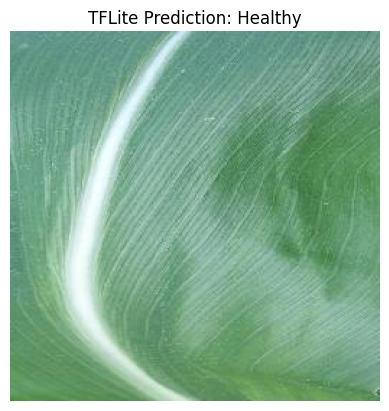

In [12]:
plt.imshow(image.load_img(img_path))
plt.title(f"TFLite Prediction: {predicted_label}")
plt.axis('off')
plt.show()
